In [192]:
import numpy as np

# ============================================================
# Constants (cgs)
# ============================================================
AU   = 1.495978707e13
RSUN = 6.957e10
SIGMA_SB = 5.670374419e-5
PI = np.pi

# ============================================================
# User / model parameters (toy Dullemond-like)
# ============================================================
Teff   = 3000.0
Rstar  = 2.0 * RSUN

Sigma_1AU = 1e3
pSigma    = 1.0

R = 1.0 * AU
Sigma = Sigma_1AU * (R / AU) ** (-pSigma)

# Prescribed Gaussian density scale height (NOT iterated)
Hscale = 0.05 * R

# Eddington/Marshak boundary parameter (Two stream approximation)
psi = 1.0 / np.sqrt(3.0)

# Grazing beam
mu0 = 0.05

# Grid
nz = 800
zmax = 12.0 * Hscale
p_stretch = 1.0  # cluster points toward surface
s = np.linspace(0.0, 1.0, nz)
z = zmax * s**p_stretch

# Density profile (upper half)
rho0 = Sigma / (np.sqrt(2*PI) * Hscale)
rho = rho0 * np.exp(-0.5 * (z/Hscale)**2)

# ============================================================
# Opacity model (placeholder power laws)
# ============================================================
Tref = 100.0
kappaP0 = 1.0
kappaR0 = 1.0
betaP  = 1.0
betaR  = 1.0

def kappaP(T):
    T = np.maximum(T, 1.0)
    return kappaP0 * (T/Tref)**betaP

def kappaR(T):
    T = np.maximum(T, 1.0)
    return kappaR0 * (T/Tref)**betaR

# Stellar absorption opacity (placeholder)
kappa_star = kappaP(Teff)


def stellar_heating_q(rho, z, kappa_star, F_star, mu0):
    """
    Simple 1D attenuated grazing beam from +z:
        tau(z) = ∫_z^∞ rho kappa_star dz'
        q(z) = rho kappa_star F_star * exp(-tau/mu0)
    (Units: erg cm^-3 s^-1)

    This is a simplified 'direct irradiation' heating profile.
    """
    # optical depth from top downward (compute on upper-half grid)
    # tau_top[i] = ∫_{z[i]}^{zmax} rho*kappa dz
    integrand = rho * kappa_star
    tau_top = np.zeros_like(z)
    # cumulative trapezoid from top to bottom
    for i in range(len(z)-2, -1, -1):
        tau_top[i] = tau_top[i+1] + 0.5*(integrand[i]+integrand[i+1])*(z[i+1]-z[i])

    q = rho * kappa_star * F_star * np.exp(-tau_top/np.maximum(mu0, 1e-6))
    return q, tau_top


# ============================================================
# Main solver: eigenvalue integration for J,H + explicit T update
# ============================================================
def solve_column(
    max_iter=300,
    tol=1e-6,
    omega_T=0.2,      # under-relaxation for T (smaller for inner radii)
    Tmin=1.0,
    Tmax=8000.0,
    rho_floor=1e-80,
    kap_floor=1e-20,
    verbose=True
):
    # heating (fixed because rho fixed in this toy)
    # Stellar flux at radius R (normal incidence)
    F_star = (Rstar/R)**2 * SIGMA_SB * Teff**4  # erg/cm^2/s
    q, tau = stellar_heating_q(rho, z, kappa_star, F_star, mu0)

    # initial guess
    T = 150.0 * np.ones_like(z)

    for it in range(max_iter):
        Told = T.copy()

        # Opacities from last iterate
        kapR = np.maximum(kappaR(T), kap_floor)
        kapP_old = np.maximum(kappaP(T), kap_floor)  # lagged kappa_P

        # ------------------------------------------------------------
        # (1) Integrate H from midplane using dH/dz = q/(4π), H(0)=0
        # ------------------------------------------------------------
        Hmom = np.zeros_like(z)
        for i in range(1, len(z)):
            Hmom[i] = Hmom[i-1] + 0.5*(q[i]+q[i-1])*(z[i]-z[i-1])/(4.0*PI)

        # ------------------------------------------------------------
        # (2) Compute eigenvalue J0 from surface BC: H(zmax) = psi J(zmax)
        # dJ/dz = -3 rho kappa_R H  ->  J(zmax) = J0 - ∫ 3 rho kappa_R H dz
        # => J0 = Hs/psi + ∫ 3 rho kappa_R H dz
        # ------------------------------------------------------------
        integrand = 3.0 * rho * kapR * Hmom
        I = np.trapz(integrand, z)
        Hs = Hmom[-1]
        J0 = Hs/psi + I
        J0 = max(J0, 0.0)

        # ------------------------------------------------------------
        # (3) Integrate J upward: dJ/dz = -3 rho kappa_R H, with J(0)=J0
        # ------------------------------------------------------------
        J = np.zeros_like(z)
        J[0] = J0
        for i in range(1, len(z)):
            dJdz_L = -3.0 * rho[i-1] * kapR[i-1] * Hmom[i-1]
            dJdz_R = -3.0 * rho[i]   * kapR[i]   * Hmom[i]
            J[i] = J[i-1] + 0.5*(dJdz_L + dJdz_R)*(z[i]-z[i-1])

        # clip any tiny negative numerical noise
        J = np.maximum(J, 0.0)

        # ------------------------------------------------------------
        # (4) Explicit T update (lagged kappa_P):
        #     (σ/π) T^4 = J + q/(4π ρ κP(T_old))
        # ------------------------------------------------------------
        rho_eff = np.maximum(rho, rho_floor)
        source = J + q / (4.0*PI*rho_eff*kapP_old)
        source = np.maximum(source, 0.0)

        T_explicit = ((PI / SIGMA_SB) * source) ** 0.25
        T_explicit = np.clip(T_explicit, Tmin, Tmax)

        # under-relaxation
        T = (1.0 - omega_T) * T + omega_T * T_explicit
        T = np.clip(T, Tmin, Tmax)

        # ------------------------------------------------------------
        # convergence + diagnostics
        # ------------------------------------------------------------
        rel = np.max(np.abs((T - Told) / np.maximum(Told, 1.0)))

        if verbose and (it % 10 == 0 or rel < tol):
            Fabs = np.trapz(q, z)             # should be ~ F0 if zmax high enough
            print(
                f"iter={it:4d} rel={rel:.3e}  "
                f"Tmid={T[0]:.2f}  Tsfc={T[-1]:.2f}  "
                f"minJ={J.min():.3e} maxJ={J.max():.3e}  "
                f"Hs={Hs:.3e} J0={J0:.3e}  "
                f"minq={q.min():.3e} maxq={q.max():.3e}"
            )

        if rel < tol:
            break

    # mirror to full z (optional)
    #z_full = np.concatenate((-z[:0:-1], z))
    #T_full = np.concatenate((T[:0:-1], T))
    #J_full = np.concatenate((J[:0:-1], J))
    #rho_full = np.concatenate((rho[:0:-1], rho))
    #q_full = np.concatenate((q[:0:-1], q))
    #H_full = np.concatenate((-Hmom[:0:-1], Hmom))  # antisymmetric

    return z, rho, q, Hmom, J, T,

# ============================================================
# Run
# ============================================================
if __name__ == "__main__":
    zf, rhof, qf, Hf, Jf, Tf, = solve_column(
        max_iter=400,
        tol=1e-6,
        omega_T=0.15,   # try 0.1–0.3; smaller is safer for inner radii
        verbose=True
    )
    mid = len(zf)//2
    print("\nDone.")
    print(f"Midplane: T={Tf[mid]:.2f} K, J={Jf[mid]:.3e}")


iter=   0 rel=2.831e-01  Tmid=144.16  Tsfc=192.47  minJ=2.737e+03 maxJ=2.749e+03  Hs=1.580e+03 J0=2.749e+03  minq=0.000e+00 maxq=4.739e-08
iter=  10 rel=1.311e-02  Tmid=117.67  Tsfc=332.27  minJ=2.737e+03 maxJ=2.759e+03  Hs=1.580e+03 J0=2.759e+03  minq=0.000e+00 maxq=4.739e-08
iter=  20 rel=1.990e-03  Tmid=112.47  Tsfc=348.44  minJ=2.737e+03 maxJ=2.760e+03  Hs=1.580e+03 J0=2.760e+03  minq=0.000e+00 maxq=4.739e-08
iter=  30 rel=3.953e-04  Tmid=111.45  Tsfc=350.46  minJ=2.737e+03 maxJ=2.760e+03  Hs=1.580e+03 J0=2.760e+03  minq=0.000e+00 maxq=4.739e-08
iter=  40 rel=7.789e-05  Tmid=111.25  Tsfc=350.71  minJ=2.737e+03 maxJ=2.760e+03  Hs=1.580e+03 J0=2.760e+03  minq=0.000e+00 maxq=4.739e-08
iter=  50 rel=1.533e-05  Tmid=111.21  Tsfc=350.74  minJ=2.737e+03 maxJ=2.760e+03  Hs=1.580e+03 J0=2.760e+03  minq=0.000e+00 maxq=4.739e-08
iter=  60 rel=3.016e-06  Tmid=111.21  Tsfc=350.75  minJ=2.737e+03 maxJ=2.760e+03  Hs=1.580e+03 J0=2.760e+03  minq=0.000e+00 maxq=4.739e-08
iter=  67 rel=9.667e-07  Tm

/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_26815/3826405839.py:126: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I = np.trapz(integrand, z)
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_26815/3826405839.py:165: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Fabs = np.trapz(q, z)             # should be ~ F0 if zmax high enough


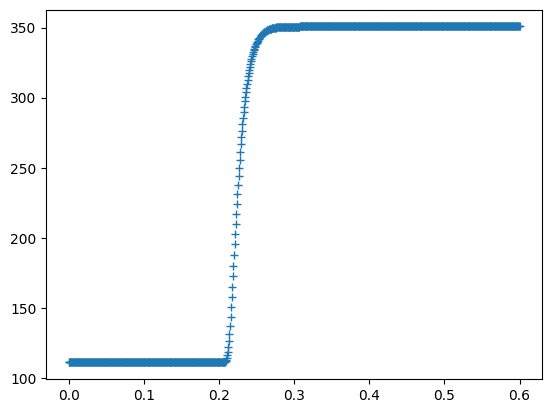

In [76]:
import matplotlib.pyplot as plt
plt.plot(zf/AU, Tf, '+')

[]

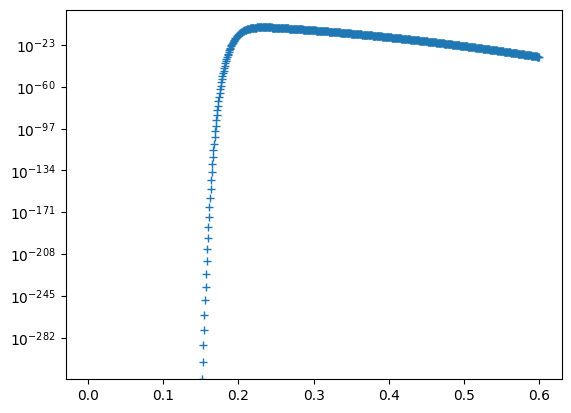

In [77]:
plt.plot(zf/AU, qf, '+')
plt.plot()
plt.semilogy()

(10000.0, 100000000.0)

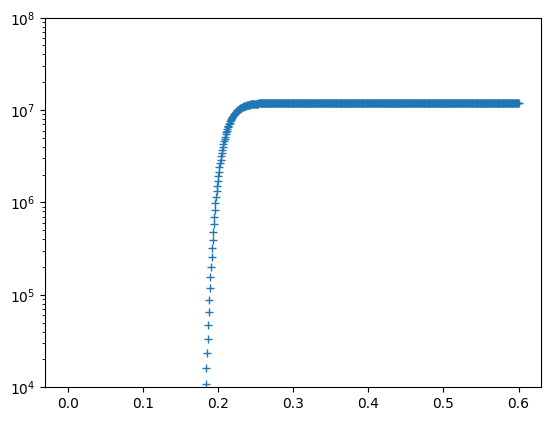

In [10]:
plt.plot(zf/AU, qf / rhof, '+')
plt.semilogy()
plt.ylim(1e4, 1e8)

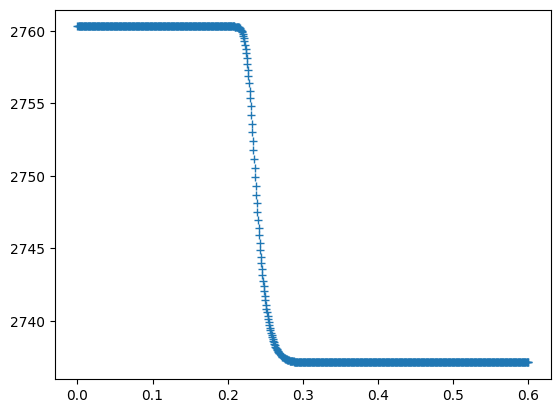

In [132]:
plt.plot(zf/AU, Jf, '+')
#plt.plot(zf/AU, Hf, '+')

In [98]:
import numpy as np

# -----------------------------
# Physical constants (cgs)
# -----------------------------
C_LIGHT  = 2.99792458e10
SIGMA_SB = 5.670374419e-5
A_RAD    = 4.0 * SIGMA_SB / C_LIGHT   # radiation constant a_R = 4 sigma / c

# -----------------------------
# Utility: complex tridiagonal solver (Thomas algorithm)
# -----------------------------
def solve_tridiag_complex(a, b, c, r):
    """
    Solve tridiagonal system with complex coefficients:
      a[i]*x[i-1] + b[i]*x[i] + c[i]*x[i+1] = r[i]
    where a[0]=0, c[-1]=0.
    """
    n = len(b)
    a = a.astype(complex).copy()
    b = b.astype(complex).copy()
    c = c.astype(complex).copy()
    r = r.astype(complex).copy()

    # Forward elimination
    for i in range(1, n):
        w = a[i] / b[i-1]
        b[i] -= w * c[i-1]
        r[i] -= w * r[i-1]

    # Back substitution
    x = np.zeros(n, dtype=complex)
    x[-1] = r[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (r[i] - c[i] * x[i+1]) / b[i]
    return x

# -----------------------------
# Main solver: master equation for E_m(z)
# -----------------------------
def solve_master_mode(
    z, rho_g, rho_d, T0, Q0,
    kappaP_func, kappaR_func,
    R, Omega, m,
    A_shadow=0.2,                 # Q = Q0*(1 + A cos m phi) => Qm = (A/2)Q0
    gamma_g=1.4,                  # gas adiabatic index for your cp/cv factor
    c_d=1.0e7,                    # dust specific heat [erg g^-1 K^-1] (set as needed)
    beta_col_d=None,              # array beta_col,d(z) = Omega t_col,d
    beta_col_g=None,              # array beta_col,g(z) = Omega t_col,g
    beta_rad_d=None,              # array beta_rad,d(z) = Omega t_rad,d (computed if None)
    include_dkappa_dT=False,      # if True, include d kappaP / dT term in t_rad,d
    lambda0=1.0/3.0,              # Eddington diffusion
    top_bc="marshak"              # "marshak" recommended
):
    """
    Solves for complex amplitudes:
      E_m(z), T_d,m(z), T_g,m(z)
    using your beta-form PDE reduced with Fourier mode m.

    Inputs:
      - background arrays: z, rho_g, rho_d, T0, Q0 (upper half)
      - opacities per dust mass: kappaP_func(T), kappaR_func(T)
      - geometry: R (cm), Omega (s^-1), m (int)
      - shadow amplitude A_shadow: Qm(z) = 0.5*A_shadow*Q0(z)
      - betas: beta_col_d(z), beta_col_g(z), beta_rad_d(z)
        If beta_rad_d is None, it's computed from your conventional formula:
          t_rad,d = c_d / [16 sigma kappaP(T0) T0^3 + 4 sigma (dkappaP/dT) T0^4]
        with optional dkappa/dT.
    """

    z     = np.asarray(z, dtype=float)
    rho_g = np.asarray(rho_g, dtype=float)
    rho_d = np.asarray(rho_d, dtype=float)
    T0    = np.asarray(T0, dtype=float)
    Q0    = np.asarray(Q0, dtype=float)
    nz = len(z)
    assert nz >= 3, "Need at least 3 grid points."

    # Forcing mode (cosine perturbation): Qm = (A/2) Q0
    Qm = 0.5 * A_shadow * Q0  # [erg cm^-3 s^-1], real-valued amplitude

    # Background opacity arrays (per dust mass)
    kapP = np.asarray(kappaP_func(T0), dtype=float)
    kapR = np.asarray(kappaR_func(T0), dtype=float)

    # eta = d(aT^4)/dT = 4 a_R T0^3
    eta = 4.0 * A_RAD * T0**3

    # Diffusion coefficient D(z) = c / (3 rho_d kappa_R)
    D = C_LIGHT * lambda0 / (rho_d * kapR)  # since lambda0=1/3 => c/(3 rho_d kappa_R)

    # -----------------------------
    # beta_rad,d from your conventional definition (if not provided)
    # t_rad,d = c_d / [16 sigma kappaP T0^3 + 4 sigma (dkappaP/dT) T0^4]
    # beta_rad,d = Omega t_rad,d
    # -----------------------------
    if beta_rad_d is None:
        if include_dkappa_dT:
            # numerical derivative of kappaP(T): dkappa/dT at T0
            # (safe small step)
            eps = 1e-3
            T_plus  = T0 * (1.0 + eps)
            T_minus = T0 * (1.0 - eps)
            dk_dT = (kappaP_func(T_plus) - kappaP_func(T_minus)) / (T_plus - T_minus)
            denom = 16.0 * SIGMA_SB * kapP * T0**3 + 4.0 * SIGMA_SB * dk_dT * T0**4
        else:
            denom = 16.0 * SIGMA_SB * kapP * T0**3
        t_rad_d = c_d / np.maximum(denom, 1e-200)
        beta_rad_d = Omega * t_rad_d
    else:
        beta_rad_d = np.asarray(beta_rad_d, dtype=float)

    # Collision betas must be provided
    assert beta_col_d is not None and beta_col_g is not None, \
        "Provide beta_col_d(z) and beta_col_g(z)."
    beta_col_d = np.asarray(beta_col_d, dtype=float)
    beta_col_g = np.asarray(beta_col_g, dtype=float)

    # -----------------------------
    # Build algebraic coefficients for Td in terms of E and forcing
    # From your derived:
    #   (im + 1/beta_rad + (im*gamma*beta_col_g)/(beta_col_d*(1+im*gamma*beta_col_g))) Td
    #     = Theta + (1/beta_rad) * (E/eta)
    # where Theta = Qm / (rho_d c_d Omega) [K]
    # -----------------------------
    ig = 1j
    Theta = Qm / (rho_d * c_d * Omega)  # [K]

    denom_g = 1.0 + ig * m * gamma_g * beta_col_g  # dimensionless, complex
    D_T = (ig * m
           + 1.0 / beta_rad_d
           + (ig * m * gamma_g * beta_col_g) / (beta_col_d * denom_g))

    # Td = (Theta + (1/beta_rad)*(E/eta)) / D_T
    # => (E/eta - Td) = (E/eta) - [Theta + (1/beta_rad)*(E/eta)]/D_T
    #                = (E/eta) * [1 - (1/beta_rad)/D_T] - Theta/D_T
    # Define:
    A_E = (1.0 / eta) * (1.0 - (1.0 / beta_rad_d) / D_T)      # multiplies E
    B_Q = - Theta / D_T                                        # additive term (K)
    # RHS of E-ODE uses (rho_d c_d Omega / beta_rad) * (E/eta - Td)
    # which becomes:
    #   RHS = (rho_d c_d Omega / beta_rad) * [ A_E * E + B_Q ]
    RHS_E_coef = (rho_d * c_d * Omega) / beta_rad_d            # [erg cm^-3 K^-1 s^-1] / 1
    # Note: A_E has units 1/(erg cm^-3)?? check:
    # eta has units [erg cm^-3 K^-1], so 1/eta is [K/(erg cm^-3)].
    # Thus A_E*E gives K. B_Q is K. RHS_E_coef*(K) gives erg cm^-3 s^-1: consistent.

    # -----------------------------
    # Master ODE for E:
    #   d/dz(D dE/dz) - (D m^2 / R^2) E = RHS_E_coef * (A_E * E + B_Q)
    # Rearranged:
    #   d/dz(D dE/dz) - [D m^2 / R^2 + RHS_E_coef*A_E] E = RHS_E_coef * B_Q
    #
    # We'll discretize in conservative form:
    #   ( D_{i+1/2}(E_{i+1}-E_i)/dz_{i+1/2} - D_{i-1/2}(E_i-E_{i-1})/dz_{i-1/2} ) / dz_c
    #   - K_i * E_i = S_i
    # where K_i = D_i m^2 / R^2 + RHS_E_coef[i]*A_E[i], S_i = RHS_E_coef[i]*B_Q[i]
    # -----------------------------
    K = D * (m**2) / (R**2) + RHS_E_coef * A_E
    S = RHS_E_coef * B_Q

    # Interface diffusion coefficient (harmonic mean is robust)
    D_ip = 2.0 * D[:-1] * D[1:] / np.maximum(D[:-1] + D[1:], 1e-300)
    dz_ip = z[1:] - z[:-1]

    # Cell width for conservative operator (nonuniform ok)
    dz_c = np.zeros(nz)
    dz_c[1:-1] = 0.5 * (z[2:] - z[:-2])
    dz_c[0] = dz_c[1]
    dz_c[-1] = dz_c[-2]

    # Tridiagonal arrays
    a = np.zeros(nz, dtype=complex)  # lower diag
    b = np.zeros(nz, dtype=complex)  # main diag
    c = np.zeros(nz, dtype=complex)  # upper diag
    r = np.zeros(nz, dtype=complex)  # rhs

    # Interior nodes
    for i in range(1, nz-1):
        Di_m = D_ip[i-1] / dz_ip[i-1]     # D_{i-1/2}/dz_{i-1/2}
        Di_p = D_ip[i]   / dz_ip[i]       # D_{i+1/2}/dz_{i+1/2}

        a[i] =  Di_m / dz_c[i]
        c[i] =  Di_p / dz_c[i]
        b[i] = -(Di_m + Di_p) / dz_c[i] - K[i]
        r[i] =  S[i]

    # BC at z=0: symmetry dE/dz = 0 -> E1 = E0
    b[0] = 1.0 + 0.0j
    c[0] = -1.0 + 0.0j
    r[0] = 0.0 + 0.0j

    # BC at top: Marshak -D dE/dz = (c/2) E
    # Discretize one-sided: -D_{N-1/2} (E_N-1 - E_N-2)/dz + (c/2) E_N-1 = 0
    # => (-D/dz)*E_{N-2} + (D/dz + c/2)*E_{N-1} = 0
    if top_bc.lower() == "marshak":
        i = nz - 1
        Di_m = D_ip[-1] / dz_ip[-1]
        a[i] = -Di_m
        b[i] =  Di_m + 0.5 * C_LIGHT
        c[i] =  0.0
        r[i] =  0.0
    else:
        raise ValueError("Only top_bc='marshak' implemented.")

    # Solve tridiagonal for E
    E = solve_tridiag_complex(a, b, c, r)

    # Recover Td_m and Tg_m
    Td = (Theta + (1.0 / beta_rad_d) * (E / eta)) / D_T
    Tg = Td / (1.0 + ig * m * gamma_g * beta_col_g)

    return E, Td, Tg


In [99]:
# Example: choose mode and shadow amplitude
m = 0
A_shadow = 1

# Then beta_col,g follows from your heat capacity relation:
# beta_col,d = (rho_d/rho_g)*(c_d/c_v) * beta_col,g  => beta_col,g = beta_col,d * (rho_g/rho_d)*(c_v/c_d)
gamma_g = 1.4
c_v = 1.0e8   # set gas cv [erg g^-1 K^-1]
c_p = gamma_g * c_v
c_d = 1.0e7   # set dust c_d [erg g^-1 K^-1]

# Build beta_col arrays from your St prescription.
# You said: St = Omega t_s and t_col,d ∝ t_s, so beta_col,d ∝ St.
# For a simple model: beta_col,d(z) = C * St (constant with height).
St = 1e-1
Ccol_pref = 1.0  # set from your alpha_T^{-1}*(2/3)*(1/(gamma-1))*(c_d/c_v) etc.
beta_col_d = Ccol_pref * St * (c_d/c_v) *  np.ones_like(z)

rho_d = rhof
rho_g = rhof * 100

beta_col_g = beta_col_d * (rho_g/rho_d) * (c_v/c_d)

G = 6.67430e-8
Msun = 1.98847e33
Ms = 1.0 * Msun
Omega = np.sqrt(G * Ms / R**3)

# Solve master equation
E_m, Td_m, Tg_m = solve_master_mode(
    z=zf, rho_g=rho_g, rho_d=rho_d, T0=Tf, Q0=qf,
    kappaP_func=kappaP, kappaR_func=kappaR,
    R=R, Omega=Omega, m=m,
    A_shadow=A_shadow,
    gamma_g=gamma_g,
    c_d=c_d,
    beta_col_d=beta_col_d,
    beta_col_g=beta_col_g,
    beta_rad_d=None,              # compute from your formula
    include_dkappa_dT=False
)

# Reconstruct physical perturbation at some phi array
phi = np.linspace(0, 2*np.pi, 256)
# deltaTd(phi,z) = Re[Td_m(z) e^{i m phi}]
deltaTd = np.real(Td_m[:,None] * np.exp(1j*m*phi[None,:]))
deltaTg = np.real(Tg_m[:,None] * np.exp(1j*m*phi[None,:]))
deltaE  = np.real(E_m[:,None]  * np.exp(1j*m*phi[None,:]))


/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_26815/3564104338.py:33: RuntimeWarning: divide by zero encountered in scalar divide
  x[-1] = r[-1] / b[-1]
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_26815/3564104338.py:33: RuntimeWarning: invalid value encountered in scalar divide
  x[-1] = r[-1] / b[-1]
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_26815/3564104338.py:35: RuntimeWarning: invalid value encountered in scalar multiply
  x[i] = (r[i] - c[i] * x[i+1]) / b[i]
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_26815/3564104338.py:210: RuntimeWarning: invalid value encountered in divide
  Td = (Theta + (1.0 / beta_rad_d) * (E / eta)) / D_T
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_26815/1012750547.py:48: RuntimeWarning: invalid value encountered in multiply
  deltaE  = np.real(E_m[:,None]  * np.exp(1j*m*phi[None,:]))


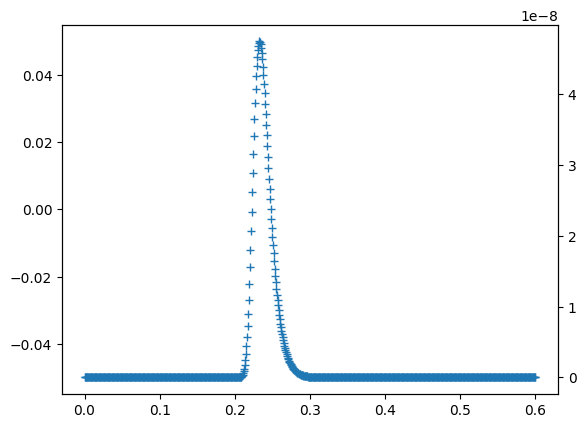

In [100]:
plt.plot(zf/AU, np.real(E_m), '+')

plt.twinx()
plt.plot(zf/AU, qf, '+')

In [84]:
import numpy as np

# -----------------------------
# Constants (cgs)
# -----------------------------
C_LIGHT  = 2.99792458e10
SIGMA_SB = 5.670374419e-5
PI       = np.pi
A_RAD    = 4.0 * SIGMA_SB / C_LIGHT  # radiation constant a_R

# -----------------------------
# Complex tridiagonal solver (Thomas)
# -----------------------------
def _solve_tridiag_complex(a, b, c, r):
    n = len(b)
    a = a.astype(complex).copy()
    b = b.astype(complex).copy()
    c = c.astype(complex).copy()
    r = r.astype(complex).copy()

    for i in range(1, n):
        w = a[i] / b[i-1]
        b[i] -= w * c[i-1]
        r[i] -= w * r[i-1]

    x = np.zeros(n, dtype=complex)
    x[-1] = r[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (r[i] - c[i] * x[i+1]) / b[i]
    return x

# -----------------------------
# m=0 Dullemond-like eigenvalue column (returns J,H,T)
# -----------------------------
def _solve_column_eigen_m0(
    z, rho_d, q0,
    kappaP_func, kappaR_func,
    psi=1.0/np.sqrt(3.0),
    max_iter=200,
    tol=1e-7,
    omega_T=0.2,
    Tmin=1.0,
    Tmax=8000.0,
    kap_floor=1e-30,
    rho_floor=1e-99,
    verbose=False,
):
    z = np.asarray(z, float)
    rho_d = np.asarray(rho_d, float)
    q0 = np.asarray(q0, float)
    nz = len(z)

    T = np.maximum(150.0, Tmin) * np.ones_like(z)

    for it in range(max_iter):
        Told = T.copy()

        kapR = np.maximum(kappaR_func(T), kap_floor)
        kapP_old = np.maximum(kappaP_func(T), kap_floor)
        rho_eff = np.maximum(rho_d, rho_floor)

        # (1) H(z): dH/dz = q/(4pi), H(0)=0
        H = np.zeros_like(z)
        for i in range(1, nz):
            H[i] = H[i-1] + 0.5*(q0[i] + q0[i-1])*(z[i]-z[i-1])/(4.0*PI)

        # (2) Eigenvalue J0 from H(zmax)=psi J(zmax)
        integrand = 3.0 * rho_eff * kapR * H
        I = np.trapz(integrand, z)
        Hs = H[-1]
        J0 = Hs/psi + I
        J0 = max(J0, 0.0)

        # (3) J(z): dJ/dz = -3 rho kappaR H, J(0)=J0
        J = np.zeros_like(z)
        J[0] = J0
        for i in range(1, nz):
            dJdz_L = -3.0 * rho_eff[i-1] * kapR[i-1] * H[i-1]
            dJdz_R = -3.0 * rho_eff[i]   * kapR[i]   * H[i]
            J[i] = J[i-1] + 0.5*(dJdz_L + dJdz_R)*(z[i]-z[i-1])
        J = np.maximum(J, 0.0)

        # (4) Explicit T update (lagged kappaP):
        # (sigma/pi) T^4 = J + q/(4pi rho kappaP_old)
        source = J + q0 / (4.0*PI*rho_eff*kapP_old)
        source = np.maximum(source, 0.0)
        T_new = ((PI/SIGMA_SB) * source)**0.25
        T_new = np.clip(T_new, Tmin, Tmax)

        T = (1.0-omega_T)*T + omega_T*T_new

        rel = np.max(np.abs((T - Told)/np.maximum(Told, 1.0)))
        if verbose and (it % 10 == 0 or rel < tol):
            print(f"[m=0 eigen] it={it:4d} rel={rel:.3e} Tmid={T[0]:.2f} Tsfc={T[-1]:.2f} J0={J0:.3e} Hs={Hs:.3e}")
        if rel < tol:
            break

    return J, H, T

# -----------------------------
# beta_rad,d from your conventional formula
# t_rad,d = c_d / [16 sigma kappaP T^3 + 4 sigma (dkappa/dT) T^4]
# -----------------------------
def _compute_beta_rad_d(T0, kappaP_func, Omega, c_d, include_dkappa_dT=False):
    T0 = np.asarray(T0, float)
    kapP = np.asarray(kappaP_func(T0), float)

    if include_dkappa_dT:
        eps = 1e-3
        Tp = T0*(1+eps)
        Tm = T0*(1-eps)
        dk_dT = (kappaP_func(Tp) - kappaP_func(Tm)) / np.maximum(Tp-Tm, 1e-99)
        denom = 16.0*SIGMA_SB*kapP*T0**3 + 4.0*SIGMA_SB*dk_dT*T0**4
    else:
        denom = 16.0*SIGMA_SB*kapP*T0**3

    t_rad = c_d / np.maximum(denom, 1e-200)  # [s]
    return Omega * t_rad

# -----------------------------
# Public API: solve_master_mode (same interface you asked for)
# -----------------------------
def solve_master_mode(
    z, rho_g, rho_d, T0, Q0,
    kappaP_func, kappaR_func,
    R, Omega, m,
    A_shadow=0.2,
    gamma_g=1.4,
    c_d=1.0e7,
    beta_col_d=None,
    beta_col_g=None,
    beta_rad_d=None,
    include_dkappa_dT=False,
    # numerics:
    max_iter=200,
    tol=1e-7,
    omega_E=0.5,      # under-relaxation for E in fixed-point loop
    psi=1.0/np.sqrt(3.0),
    top_bc="marshak",
    verbose=False,
):
    """
    Returns complex amplitudes (E_m, Td_m, Tg_m) on z-grid.

    - If m==0: uses Dullemond-like eigenvalue integration for J,H,T;
              returns E0 = (4pi/c) J0, Td0=T, Tg0=T (axisymmetric equilibrium).
              A_shadow is ignored (m=0 has no azimuthal variation).
    - If m>0: fixed-point iteration:
          (i) given Td_m, solve diffusion ODE for E_m with forcing and coupling
         (ii) update Td_m and Tg_m algebraically from E_m
        iterate to convergence with damping.
    """

    z = np.asarray(z, float)
    rho_g = np.asarray(rho_g, float)
    rho_d = np.asarray(rho_d, float)
    T0 = np.asarray(T0, float)
    Q0 = np.asarray(Q0, float)
    nz = len(z)

    # ---- m==0: return to Dullemond column (J,H eigenvalue) ----
    #if int(m) == 0:
    if False:
        J, H, T = _solve_column_eigen_m0(
            z=z, rho_d=rho_d, q0=Q0,
            kappaP_func=kappaP_func, kappaR_func=kappaR_func,
            psi=psi, max_iter=max_iter, tol=tol,
            omega_T=0.2, verbose=verbose
        )
        E = (4.0*PI/C_LIGHT) * J          # radiation energy density
        Td = T.astype(complex)
        Tg = T.astype(complex)
        return E.astype(complex), Td, Tg

    # ---- m>0: need betas ----
    if beta_col_d is None or beta_col_g is None:
        raise ValueError("For m>0, please provide beta_col_d(z) and beta_col_g(z).")

    beta_col_d = np.asarray(beta_col_d, float)
    beta_col_g = np.asarray(beta_col_g, float)

    if beta_rad_d is None:
        beta_rad_d = _compute_beta_rad_d(T0, kappaP_func, Omega, c_d, include_dkappa_dT)
    else:
        beta_rad_d = np.asarray(beta_rad_d, float)

    # Background coefficients
    kapP0 = np.asarray(kappaP_func(T0), float)
    kapR0 = np.asarray(kappaR_func(T0), float)
    eta0  = 4.0 * A_RAD * T0**3  # [erg cm^-3 K^-1]

    # diffusion coefficient D(z) = c/(3 rho_d kappa_R)
    D = C_LIGHT / (3.0 * np.maximum(rho_d*kapR0, 1e-99))

    # forcing mode: Qm = (A/2) Q0 (cosine perturbation)
    Qm = 0.5 * A_shadow * Q0   # [erg cm^-3 s^-1] real amplitude
    Theta = Qm / (np.maximum(rho_d, 1e-99) * c_d * Omega)  # [K]

    ig = 1j

    # ---- build diffusion operator matrices once (conservative form) ----
    dz_ip = z[1:] - z[:-1]
    dz_c = np.zeros(nz)
    dz_c[1:-1] = 0.5*(z[2:] - z[:-2])
    dz_c[0] = dz_c[1]
    dz_c[-1] = dz_c[-2]

    # harmonic mean of D on interfaces
    D_ip = 2.0*D[:-1]*D[1:] / np.maximum(D[:-1]+D[1:], 1e-300)

    # Tridiagonal skeleton for L[E] = d/dz(D dE/dz) - (D m^2 / R^2) E
    # We'll add coupling/source terms each iteration.
    def build_L_tridiag(mass_term):
        """
        mass_term[i] is added as:  - mass_term[i] * E[i] on LHS
        i.e. equation: (diff_op) - mass_term*E = rhs
        """
        a = np.zeros(nz, dtype=complex)
        b = np.zeros(nz, dtype=complex)
        c = np.zeros(nz, dtype=complex)
        r = np.zeros(nz, dtype=complex)

        for i in range(1, nz-1):
            Di_m = D_ip[i-1] / dz_ip[i-1]
            Di_p = D_ip[i]   / dz_ip[i]
            a[i] =  Di_m / dz_c[i]
            c[i] =  Di_p / dz_c[i]
            b[i] = -(Di_m + Di_p)/dz_c[i] - mass_term[i]
            # r[i] set outside

        # midplane symmetry: dE/dz=0 => E1 = E0
        b[0] = 1.0 + 0j
        c[0] = -1.0 + 0j
        r[0] = 0.0 + 0j

        # top BC
        if top_bc.lower() == "marshak":
            # -D dE/dz = (c/2) E  at zmax
            i = nz-1
            Di_m = D_ip[-1] / dz_ip[-1]
            a[i] = -Di_m
            b[i] =  Di_m + 0.5*C_LIGHT
            c[i] =  0.0
            r[i] =  0.0
        else:
            raise ValueError("Only top_bc='marshak' implemented.")

        return a,b,c,r

    # ---- fixed-point iteration ----
    # initial guess: local LTE-ish relation E ~ eta*T0*Td_m amplitude ~ eta*Theta
    E = (eta0 * Theta).astype(complex)

    for it in range(max_iter):
        E_old = E.copy()

        # --- (1) update Td_m, Tg_m algebraically given E ---
        # gas response:
        denom_g = 1.0 + ig*m*gamma_g*beta_col_g
        # dust thermal denominator:
        D_T = (ig*m
               + 1.0/beta_rad_d
               + (ig*m*gamma_g*beta_col_g) / (beta_col_d * denom_g))

        Td = (Theta + (1.0/beta_rad_d) * (E/eta0)) / D_T
        Tg = Td / denom_g

        # --- (2) solve diffusion ODE for E with Td held fixed ---
        # Radiation equation (mode form):
        #   d/dz(D dE/dz) - (D m^2/R^2) E = rho_d kappa_P c (eta Td - E)
        # Move RHS to LHS:
        #   d/dz(D dE/dz) - (D m^2/R^2) E + rho_d kappa_P c E = rho_d kappa_P c eta Td
        chi = np.maximum(rho_d, 1e-99) * kapP0 * C_LIGHT  # rho_d kappa_P c
        mass_term = D*(m**2)/(R**2) + chi  # appears with minus sign in our b[i] convention

        a,b,c,r = build_L_tridiag(mass_term=mass_term.astype(complex))

        # RHS: chi * eta * Td
        rhs = (chi * eta0 * Td).astype(complex)
        r[1:-1] = rhs[1:-1]

        E_new = _solve_tridiag_complex(a,b,c,r)

        # under-relaxation (critical for stiff surface layers)
        E = (1.0-omega_E)*E + omega_E*E_new

        # convergence
        rel = np.max(np.abs(E - E_old) / np.maximum(np.abs(E_old), 1e-30))
        if verbose and (it % 10 == 0 or rel < tol):
            print(f"[m={m}] it={it:4d} rel={rel:.3e} |E|max={np.max(np.abs(E)):.3e} |Td|max={np.max(np.abs(Td)):.3e}")
        if rel < tol:
            break

    # final Td,Tg consistent with final E
    denom_g = 1.0 + ig*m*gamma_g*beta_col_g
    D_T = (ig*m
           + 1.0/beta_rad_d
           + (ig*m*gamma_g*beta_col_g) / (beta_col_d * denom_g))
    Td = (Theta + (1.0/beta_rad_d) * (E/eta0)) / D_T
    Tg = Td / denom_g

    return E, Td, Tg


In [96]:
# Example: choose mode and shadow amplitude
m = 0
A_shadow = 1

# Then beta_col,g follows from your heat capacity relation:
# beta_col,d = (rho_d/rho_g)*(c_d/c_v) * beta_col,g  => beta_col,g = beta_col,d * (rho_g/rho_d)*(c_v/c_d)
gamma_g = 1.4
c_v = 1.0e8   # set gas cv [erg g^-1 K^-1]
c_p = gamma_g * c_v
c_d = 1.0e7   # set dust c_d [erg g^-1 K^-1]

# Build beta_col arrays from your St prescription.
# You said: St = Omega t_s and t_col,d ∝ t_s, so beta_col,d ∝ St.
# For a simple model: beta_col,d(z) = C * St (constant with height).
St = 1e-1
Ccol_pref = 1.0  # set from your alpha_T^{-1}*(2/3)*(1/(gamma-1))*(c_d/c_v) etc.
beta_col_d = Ccol_pref * St * (c_d/c_v) *  np.ones_like(z)

rho_d = rhof
rho_g = rhof * 100

beta_col_g = beta_col_d * (rho_g/rho_d) * (c_v/c_d)

G = 6.67430e-8
Msun = 1.98847e33
Ms = 1.0 * Msun
Omega = np.sqrt(G * Ms / R**3)

# Solve master equation
E_m, Td_m, Tg_m = solve_master_mode(
    z=zf, rho_g=rho_g, rho_d=rho_d, T0=Tf, Q0=qf,
    kappaP_func=kappaP, kappaR_func=kappaR,
    R=R, Omega=Omega, m=m,
    A_shadow=A_shadow,
    gamma_g=gamma_g,
    c_d=c_d,
    beta_col_d=beta_col_d,
    beta_col_g=beta_col_g,
    beta_rad_d=None,              # compute from your formula
    include_dkappa_dT=False
)

# Reconstruct physical perturbation at some phi array
phi = np.linspace(0, 2*np.pi, 256)
# deltaTd(phi,z) = Re[Td_m(z) e^{i m phi}]
deltaTd = np.real(Td_m[:,None] * np.exp(1j*m*phi[None,:]))
deltaTg = np.real(Tg_m[:,None] * np.exp(1j*m*phi[None,:]))
deltaE  = np.real(E_m[:,None]  * np.exp(1j*m*phi[None,:]))


In [232]:
import numpy as np

# -----------------------------
# Constants (cgs)
# -----------------------------
C_LIGHT  = 2.99792458e10
SIGMA_SB = 5.670374419e-5
PI       = np.pi
A_RAD    = 4.0 * SIGMA_SB / C_LIGHT  # radiation constant a_R

def _compute_beta_rad_d(T0, kappaP_func, Omega, c_d, include_dkappa_dT=False):
    """
    beta_rad_d(z) = Omega * t_rad(z)
    t_rad ≈ c_d / (16 sigma kappaP T^3)  [your conventional approximation]
    """
    T0 = np.asarray(T0, float)
    kapP = np.asarray(kappaP_func(T0), float)

    if include_dkappa_dT:
        eps = 1e-3
        Tp = T0*(1+eps)
        Tm = T0*(1-eps)
        dk_dT = (kappaP_func(Tp) - kappaP_func(Tm)) / np.maximum(Tp-Tm, 1e-99)
        denom = 16.0*SIGMA_SB*kapP*T0**3 + 4.0*SIGMA_SB*dk_dT*T0**4
    else:
        denom = 16.0*SIGMA_SB*kapP*T0**3

    t_rad = c_d / np.maximum(denom, 1e-200)
    return Omega * t_rad

def solve_master_mode_shooting(
    z, rho_g, rho_d, T0, Q0,
    kappaP_func, kappaR_func,
    R, Omega, m,
    A_shadow=0.2,
    gamma_g=1.4,
    c_d=1.0e7,
    beta_col_d=None,
    beta_col_g=None,
    beta_rad_d=None,
    include_dkappa_dT=False,
    psi=1.0/np.sqrt(3.0),
    use_shadow_heating=True,
    verbose=False,
):
    """
    Solve for ONE Fourier mode m using MEMO-like vertical shooting in z.

    Unknowns (complex amplitudes): E_m(z), Td_m(z), Tg_m(z)

    Equations (diffusion + Eddington closure in z, Fourier in phi):
      dE/dz = -Fz / D
      dFz/dz + (D m^2 / R^2) E = Qm + chi*(eta*Td - E)

    Dust+gas algebra (linearized, as you wrote):
      denom_g = 1 + i m gamma_g beta_col_g
      D_T = i m + beta_rad^-1 + (i m gamma_g beta_col_g)/(beta_col_d * denom_g)
      Td = (Theta + beta_rad^-1 * (E/eta)) / D_T
      Tg = Td / denom_g

    where:
      D = c/(3 rho_d kappaR)
      chi = rho_d kappaP c
      eta = 4 a_R T0^3
      Theta = Qm/(rho_d c_d Omega)

    Boundary conditions:
      midplane symmetry: Fz(0)=0
      surface two-stream: Fz(zmax) = psi c E(zmax)

    The shooting constant is E(0), which is complex.
    We solve it in ONE step using linearity:
      residual(E0) = F_top - psi c E_top = Rh*E0 + Rp
      => E0 = -Rp/Rh
    """

    z = np.asarray(z, float)
    rho_g = np.asarray(rho_g, float)
    rho_d = np.asarray(rho_d, float)
    T0 = np.asarray(T0, float)
    Q0 = np.asarray(Q0, float)
    nz = len(z)
    if nz < 3:
        raise ValueError("Need at least 3 z points.")

    if beta_col_d is None or beta_col_g is None:
        raise ValueError("Please provide beta_col_d(z) and beta_col_g(z).")

    beta_col_d = np.asarray(beta_col_d, float)
    beta_col_g = np.asarray(beta_col_g, float)

    if beta_rad_d is None:
        beta_rad_d = _compute_beta_rad_d(T0, kappaP_func, Omega, c_d, include_dkappa_dT)
    else:
        beta_rad_d = np.asarray(beta_rad_d, float)

    # background opacities
    kapP0 = np.asarray(kappaP_func(T0), float)
    kapR0 = np.asarray(kappaR_func(T0), float)

    # coefficients
    rho_eff = np.maximum(rho_d, 1e-99)
    kapR_eff = np.maximum(kapR0, 1e-99)
    kapP_eff = np.maximum(kapP0, 1e-99)

    D = C_LIGHT / (3.0 * rho_eff * kapR_eff)                  # [cm^2/s]
    chi = rho_eff * kapP_eff * C_LIGHT                        # [1/s] * (erg/cm^3?) -> consistent in equation
    eta = 4.0 * A_RAD * T0**3                                 # [erg cm^-3 K^-1]

    # heating mode amplitude Qm(z)
    if use_shadow_heating:
        # shadow modulation amplitude (cosine mode): Qm = (A/2) Q0
        Qm = 0.5 * A_shadow * Q0
    else:
        # if you want "mode-0 background heating" behavior, use Qm=Q0
        Qm = Q0.copy()

    # Theta(z) in K (dimensionless temperature source)
    Theta = Qm / (rho_eff * c_d * Omega)

    ig = 1j
    m = int(m)

    # --- Helper: evaluate Td(E) and Tg(E) at one z-index ---
    def Td_Tg_from_E(E, i):
        denom_g = 1.0 + ig*m*gamma_g*beta_col_g[i]
        # dust thermal denominator
        D_T = (ig*m
               + 1.0/beta_rad_d[i]
               + (ig*m*gamma_g*beta_col_g[i]) / (beta_col_d[i] * denom_g))
        Td = (Theta[i] + (1.0/beta_rad_d[i]) * (E/eta[i])) / D_T
        Tg = Td / denom_g
        return Td, Tg

    # --- RK4 integrator for the linear ODE system ---
    # State y = [E, Fz] (complex)
    def rhs(i, E, Fz, forcing_on=True):
        # forcing_on: include Qm and Theta; else set them to zero for homogeneous solve
        if forcing_on:
            Q_loc = Qm[i]
            Theta_loc = Theta[i]
        else:
            Q_loc = 0.0
            Theta_loc = 0.0

        # For homogeneous/particular split, we must also reflect Theta in Td(E).
        # Easiest: temporarily override Theta[i] via local value.
        # So compute Td with the correct local Theta_loc:
        denom_g = 1.0 + ig*m*gamma_g*beta_col_g[i]
        D_T = (ig*m
               + 1.0/beta_rad_d[i]
               + (ig*m*gamma_g*beta_col_g[i]) / (beta_col_d[i] * denom_g))
        Td = (Theta_loc + (1.0/beta_rad_d[i]) * (E/eta[i])) / D_T

        # ODEs:
        dE_dz = -Fz / D[i]
        dFz_dz = (chi[i]*(eta[i]*Td - E)
                  - (D[i] * (m**2) / (R**2)) * E)
        return dE_dz, dFz_dz

    def integrate(E0, forcing_on=True):
        E = np.zeros(nz, dtype=complex)
        F = np.zeros(nz, dtype=complex)
        E[0] = E0
        F[0] = 0.0 + 0.0j  # midplane symmetry

        for i in range(nz-1):
            dz = z[i+1] - z[i]
            if dz <= 0:
                raise ValueError("z must be strictly increasing (upper half from midplane to surface).")

            # RK4 with coefficient sampling at i, midpoint, i+1 (index-based)
            # For midpoint coefficients, use i_mid = i (good enough if grid fine); or interpolate.
            # We'll do simple linear interpolation of coefficients by evaluating at i and i+1 and averaging.
            # Implement midpoint rhs using averaged coefficients by creating a temporary index logic:
            # We'll approximate rhs at midpoint using i_mid = i and i+1 average by calling both and averaging.

            E_i, F_i = E[i], F[i]

            k1E, k1F = rhs(i, E_i, F_i, forcing_on=forcing_on)

            # midpoint estimate
            E_half = E_i + 0.5*dz*k1E
            F_half = F_i + 0.5*dz*k1F
            k2E_i, k2F_i = rhs(i,   E_half, F_half, forcing_on=forcing_on)
            k2E_p, k2F_p = rhs(i+1, E_half, F_half, forcing_on=forcing_on)
            k2E, k2F = 0.5*(k2E_i + k2E_p), 0.5*(k2F_i + k2F_p)

            # second midpoint
            E_half2 = E_i + 0.5*dz*k2E
            F_half2 = F_i + 0.5*dz*k2F
            k3E_i, k3F_i = rhs(i,   E_half2, F_half2, forcing_on=forcing_on)
            k3E_p, k3F_p = rhs(i+1, E_half2, F_half2, forcing_on=forcing_on)
            k3E, k3F = 0.5*(k3E_i + k3E_p), 0.5*(k3F_i + k3F_p)

            # endpoint
            E_end = E_i + dz*k3E
            F_end = F_i + dz*k3F
            k4E, k4F = rhs(i+1, E_end, F_end, forcing_on=forcing_on)

            E[i+1] = E_i + (dz/6.0)*(k1E + 2*k2E + 2*k3E + k4E)
            F[i+1] = F_i + (dz/6.0)*(k1F + 2*k2F + 2*k3F + k4F)

        return E, F

    # --- Homogeneous solve (forcing off) with E0=1 ---
    Eh, Fh = integrate(1.0 + 0.0j, forcing_on=False)
    Rh = Fh[-1] - psi*C_LIGHT*Eh[-1]

    # --- Particular solve (forcing on) with E0=0 ---
    Ep, Fp = integrate(0.0 + 0.0j, forcing_on=True)
    Rp = Fp[-1] - psi*C_LIGHT*Ep[-1]

    if np.abs(Rh) < 1e-60:
        raise RuntimeError("Homogeneous residual is ~0; boundary condition makes shooting singular. Check BC/coefficients.")

    # Solve for complex E0
    E0 = -Rp / Rh

    # Superpose
    E = E0*Eh + Ep
    Fz = E0*Fh + Fp

    # Recover Td_m, Tg_m algebraically everywhere
    Td = np.zeros(nz, dtype=complex)
    Tg = np.zeros(nz, dtype=complex)
    for i in range(nz):
        Td[i], Tg[i] = Td_Tg_from_E(E[i], i)

    if verbose:
        # surface BC check
        bc_err = Fz[-1] - psi*C_LIGHT*E[-1]
        print(f"[shoot m={m}] |bc_err|/|psi c E| = {np.abs(bc_err)/np.maximum(np.abs(psi*C_LIGHT*E[-1]),1e-99):.3e}")
        # midplane check
        print(f"[shoot m={m}] Fz(0) = {Fz[0]}")
        # positivity of mean intensity only meaningful for m=0; for m>0 E can be complex
        # But you can still check that the real part isn't wildly negative.

    return E, Td, Tg, Qm


In [235]:
# Example: choose mode and shadow amplitude
m = 1
A_shadow = 2

# Then beta_col,g follows from your heat capacity relation:
# beta_col,d = (rho_d/rho_g)*(c_d/c_v) * beta_col,g  => beta_col,g = beta_col,d * (rho_g/rho_d)*(c_v/c_d)
gamma_g = 1.4
c_v = 1.0e8   # set gas cv [erg g^-1 K^-1]
c_p = gamma_g * c_v
c_d = 1.0e7   # set dust c_d [erg g^-1 K^-1]

# Build beta_col arrays from your St prescription.
# You said: St = Omega t_s and t_col,d ∝ t_s, so beta_col,d ∝ St.
# For a simple model: beta_col,d(z) = C * St (constant with height).
St = 1e-2
Ccol_pref = 1.0  # set from your alpha_T^{-1}*(2/3)*(1/(gamma-1))*(c_d/c_v) etc.
beta_col_d = Ccol_pref * St * (c_d/c_v) *  np.ones_like(zf)

rho_d = rhof
rho_g = rhof * 100

beta_col_g = beta_col_d * (rho_g/rho_d) * (c_v/c_d)

G = 6.67430e-8
Msun = 1.98847e33
Ms = 1.0 * Msun
Omega = np.sqrt(G * Ms / R**3)

# Solve master equation
E_m, Td_m, Tg_m, Q_m = solve_master_mode_shooting(
    z=zf, rho_g=rho_g, rho_d=rho_d, T0=Tf, Q0=qf,
    kappaP_func=kappaP, kappaR_func=kappaR,
    R=R, Omega=Omega, m=m,
    A_shadow=A_shadow,
    gamma_g=gamma_g,
    c_d=c_d,
    beta_col_d=beta_col_d,
    beta_col_g=beta_col_g,
    beta_rad_d=None,              # compute from your formula
    include_dkappa_dT=False,
    use_shadow_heating=True,
)

In [205]:
1/0.0014349593930333125

696.8838315947977

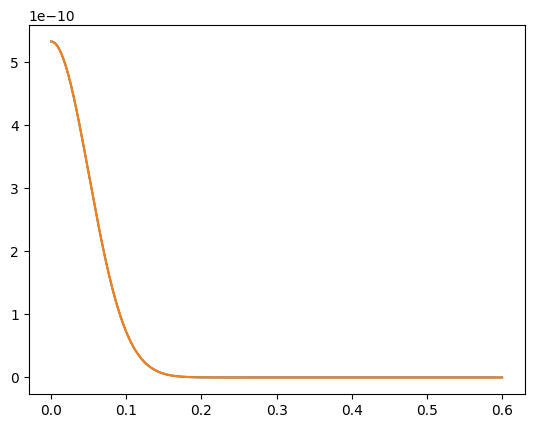

In [191]:
plt.plot(zf/AU, rho_d)
plt.plot(zf/AU, rhof)

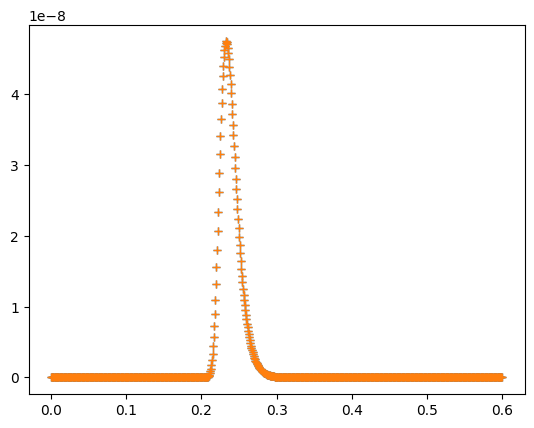

In [236]:
plt.plot(zf/AU, Q_m, '+')
plt.plot(zf/AU, qf, '+')

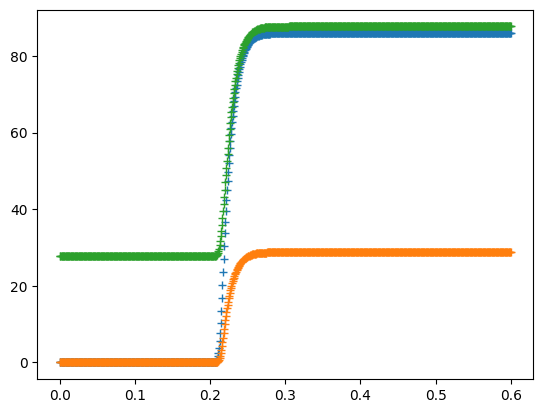

In [240]:
plt.plot(zf/AU, np.real(Td_m), '+')
plt.plot(zf/AU, np.real(Tg_m), '+')
plt.plot(zf/AU, Tf/4, '+')

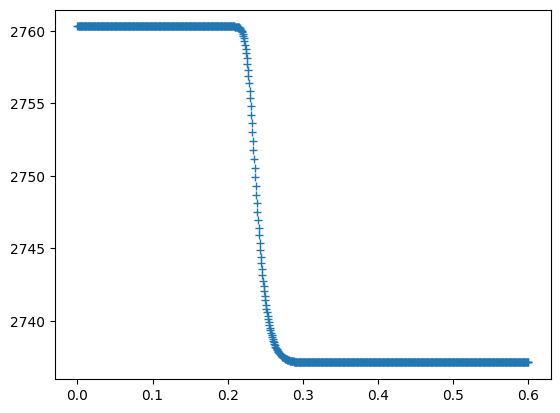

In [234]:
plt.plot(zf/AU, np.real(E_m) * C_LIGHT/(4.*np.pi), '+')

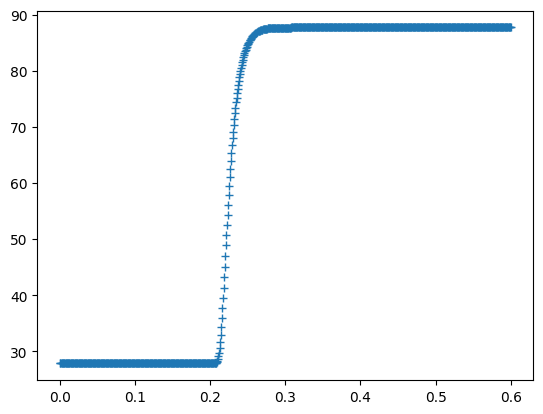

In [231]:
eta0 = 4*A_RAD*Tf**3
rhs = Q_m/(C_LIGHT*rho_d*kappaP(Tf)*eta0)
beta_rad_d = _compute_beta_rad_d(Tf, kappaP, Omega, c_d, include_dkappa_dT=False)
lhs = beta_rad_d * (Q_m/(rho_d*c_d*Omega))

plt.plot(zf/AU, rhs + E_m/eta0, '+')